In [1]:
import pickle   
import numpy as np
import matplotlib.pyplot as plt

## Loading data

In [2]:
atttention_file_path = 'open_rfcrate_box_results/widarDataset1_rfCRATEbase_rf_crate_base_0822000626open_box.pkl'
with open(atttention_file_path, 'rb') as handle:
    attentions_results = pickle.load(handle)
print(attentions_results.keys())

dict_keys(['input', 'attentions', 'kqv', 'feature', 'label', 'attr'])


In [5]:
heads = 12 # the number of heads in the attention layer

inputs = attentions_results['input']  # (736, 3, 3000, 30)  # (num_sample, link, time_index, subcarrier_index)
print(inputs.shape)

attentions = attentions_results['attentions']  # (736, 101, 768)  # (num_sample, patch_index (CLS, ...), num_heads * dim)
print(attentions.shape)
attentions = attentions.reshape(736, 101, heads, 768//heads)  # (736, 101, 12, 64)
attentions_CLS = attentions[:, 0, :, :]  # (736, 12, 64)
attentions = attentions[:, 1:, :, :]  # (736, 100, 12, 64)
print("attentions_CLS", attentions_CLS.shape)
print("attentions", attentions.shape)

qkv = attentions_results['kqv'] # (23, 32, 100, 768)  # Shape: [num_batch, batch_size, patch_index, num_heads* dim]
# combine the first two dimensions
qkv = qkv.reshape(-1, 100, 768)  # (736, 100, 768)
print(qkv.shape)
qkv = qkv.reshape(736, 100, heads, 768//heads)  # (736, 101, 12, 64)
print(qkv.shape)

feature = attentions_results['feature']  # (736, 101, 768) # (num_sample, patch_index (CLS, ...), num_heads * dim)
print(feature.shape)
feature = feature.reshape(736, 101, heads, 768//heads)  # (736, 101, 12, 64)
feature_CLS = feature[:, 0, :, :]  # (736, 12, 64)
feature = feature[:, 1:, :, :]  # (736, 100, 12, 64)
print("feature_CLS", feature_CLS.shape)
print("feature", feature.shape)

labels = attentions_results['label']   # (384,) # (num_sample) 
print('labels.shape', labels.shape)
attr = attentions_results['attr'] 
# convert to numpy array
attr = np.array(attr)
attr = attr.reshape(3, -1)  # (3: (user_id, orientation, rx), 384) # (num_attr, num_sample)
print('attr.shape', attr.shape)

(736, 3, 3000, 30)
(736, 101, 768)
attentions_CLS (736, 12, 64)
attentions (736, 100, 12, 64)
(736, 100, 768)
(736, 100, 12, 64)
(736, 101, 768)
feature_CLS (736, 12, 64)
feature (736, 100, 12, 64)
labels.shape (736,)
attr.shape (3, 736)


## subspace class relation

In [6]:
# subspace_class relation

class_subspace_dense = {
    0: [],
    1: [],
    2: [],
    3: [],
    4: [],
    5: [],
}


def normalize(data):
    data = (data - np.min(data)) / (np.max(data) - np.min(data))
    return data

num_sample = inputs.shape[0]
print(num_sample)

for select_sample in range(num_sample):
    input_sample = inputs[select_sample]  # (3, 3000, 30) complex64
    attention_sample = attentions[select_sample]  # (101, 12, 64) complex64 (patch_index, head, dim)
    attention_CLS_sample = attentions_CLS[select_sample]  # (12, 64) complex64
    kqv_sample = qkv[select_sample]  # (101, 12, 64) complex64
    feature_sample = feature[select_sample]  # (101, 12, 64) complex64; (patch_index, head, dim)
    feature_CLS_sample = feature_CLS[select_sample]  # (12, 64) complex64
    label_sample = labels[select_sample]  # () int64
    attr_sample = [a[select_sample] for a in attr]  # (3,) [int64,int64,int64]
    feature_head_density_real = np.mean(np.abs(feature_sample[:, :, :].real), axis=0)
    feature_head_density_real = normalize(np.mean(feature_head_density_real, axis=1))
    feature_head_density_imag = np.mean(np.abs(feature_sample[:, :, :].imag), axis=0)
    feature_head_density_imag = normalize(np.mean(feature_head_density_imag, axis=1))
    feature_head_density = feature_head_density_real**2 + feature_head_density_imag**2
    class_subspace_dense[label_sample].append(feature_head_density) # (num_sample, 12)


head_density_average = []
for label in class_subspace_dense.keys():
    class_subspace_dense[label] = np.array(class_subspace_dense[label])  # (num_sample, 12)
    print(class_subspace_dense[label].shape)
    head_density_average.append(class_subspace_dense[label])  # (12,)
    class_subspace_dense[label] = np.mean(class_subspace_dense[label], axis=0)  # (12,)
    class_subspace_dense[label] = normalize(class_subspace_dense[label])

head_density_average = np.concatenate(head_density_average, axis=0)  # (6, 12)
head_density_average = np.mean(head_density_average, axis=0)  # (12,)
print(head_density_average)

736
(125, 12)
(125, 12)
(122, 12)
(125, 12)
(125, 12)
(114, 12)
[0.32373357 1.1639107  0.9285703  1.3467183  0.44480225 0.3275732
 0.24769641 1.085721   0.6279209  0.09706418 0.40193614 1.0752777 ]


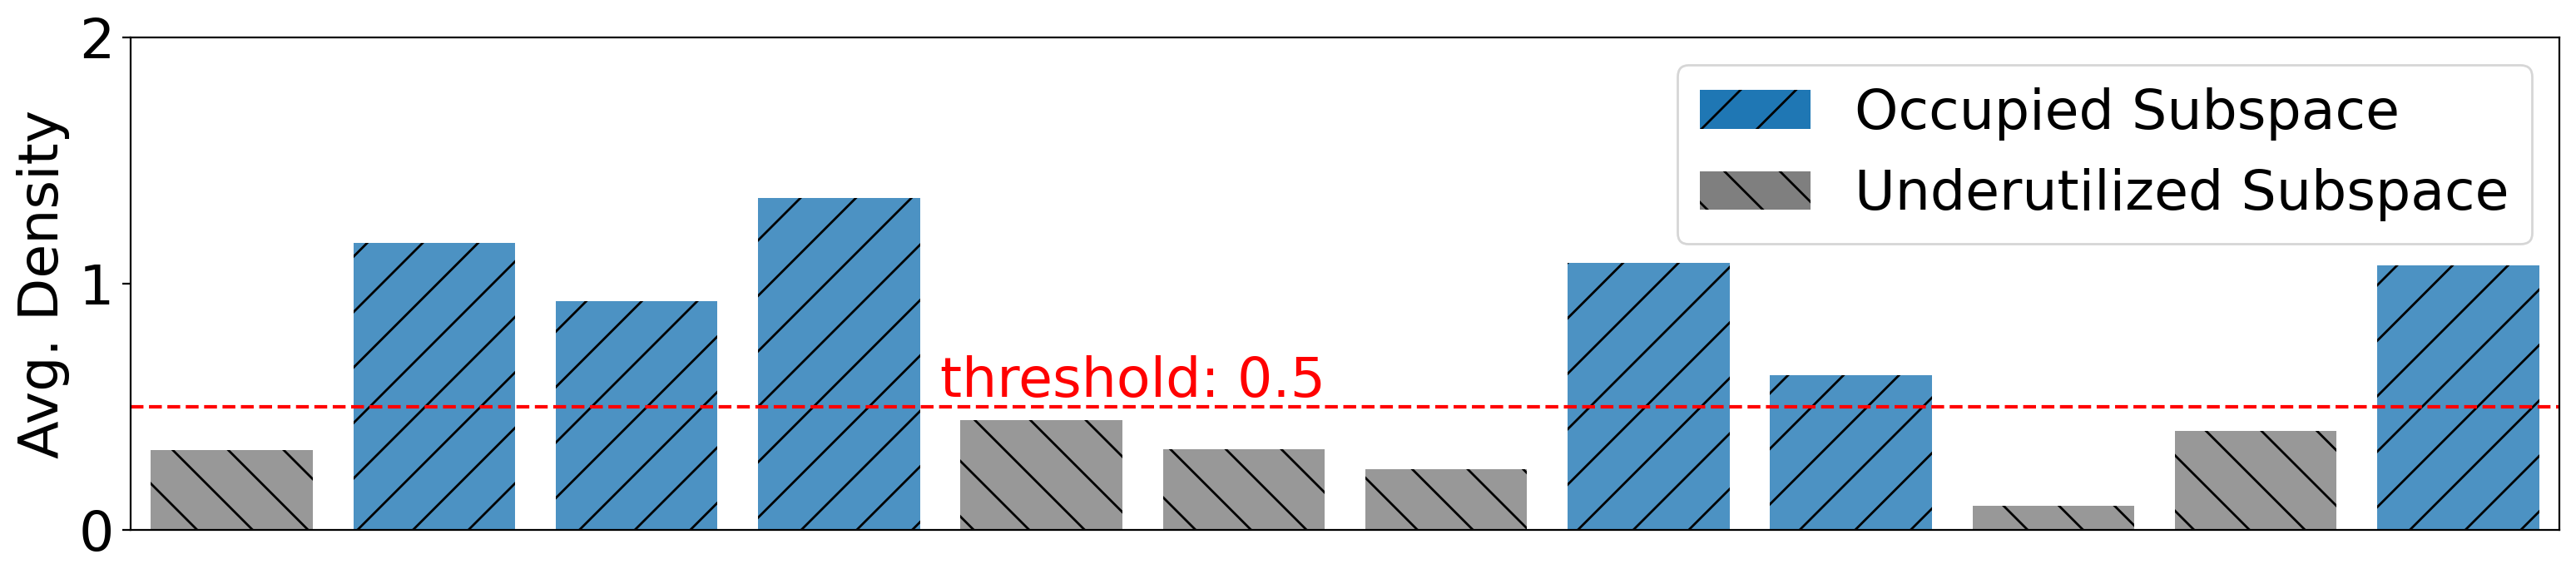

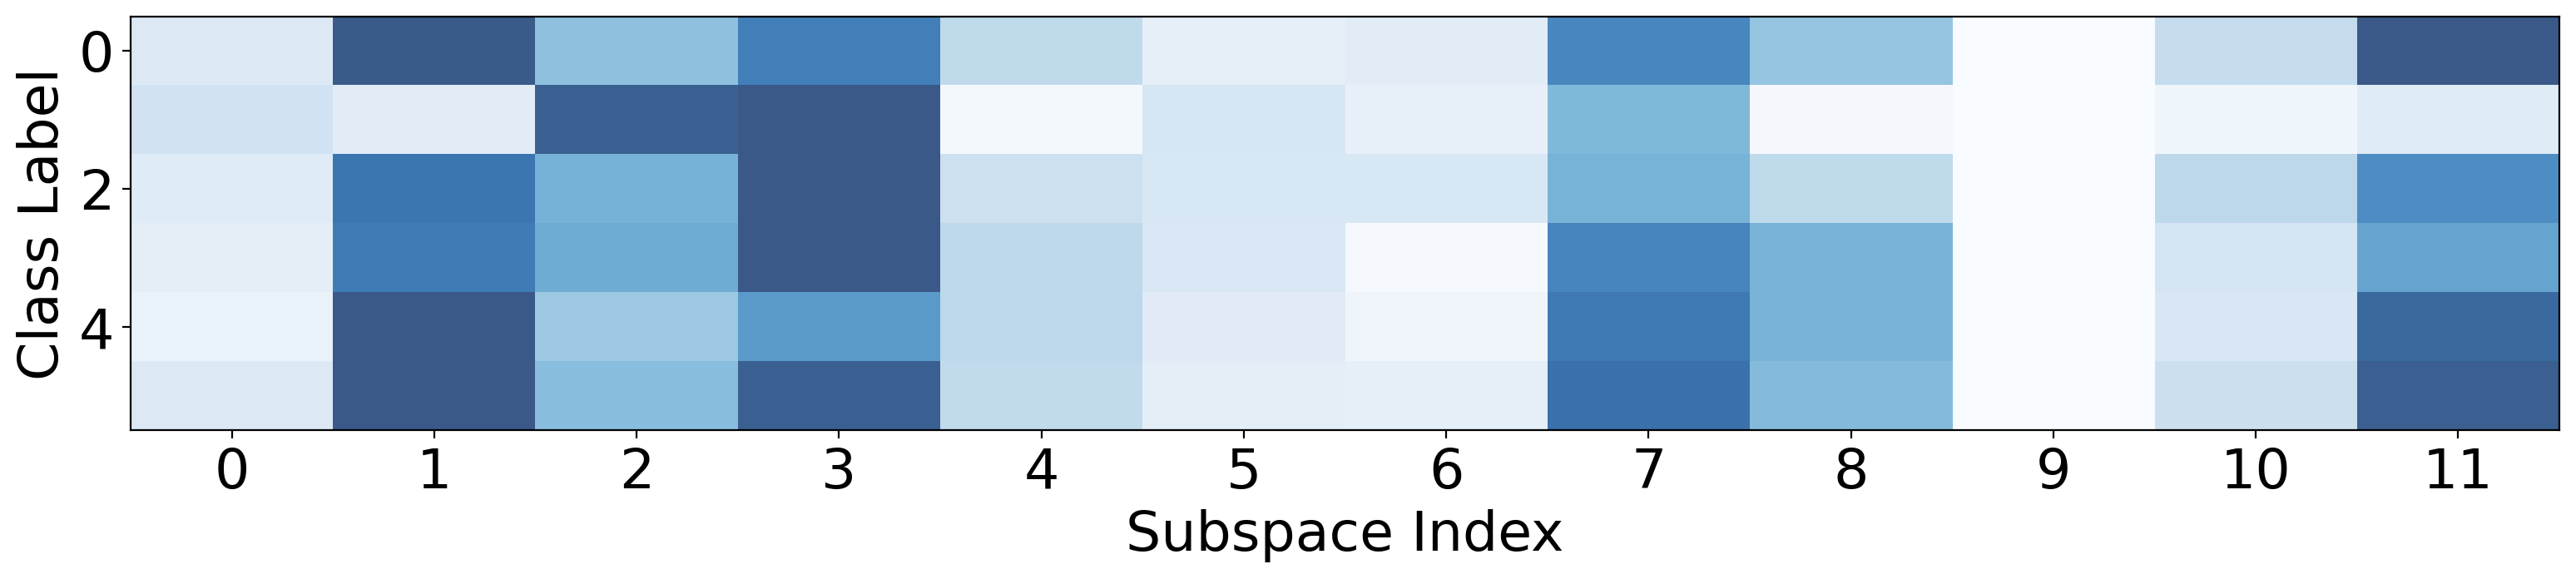

In [7]:
# draw the bar chart part
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 24}) 

alpha = 0.8

colors = ['tab:grey', 'tab:blue','tab:blue','tab:blue','tab:grey','tab:grey','tab:grey','tab:blue','tab:blue','tab:grey','tab:grey','tab:blue',]
plt.figure(figsize=(16, 4), dpi=200)

plt.bar(range(len(head_density_average)), head_density_average, color=colors, alpha=alpha)

threshold = 0.5
plt.axhline(threshold, color='red', linestyle='--')
plt.text(3.5, threshold+0.1, f'threshold: {threshold:.1f}', color='red', va='center', ha='left')

for i, density in enumerate(head_density_average):
    if density > threshold:
        plt.gca().get_children()[i].set_hatch('/')
        # plt.gca().get_children()[i].set_color('tab:blue')
        # plt.gca().get_children()[i].set_alpha(alpha)
    else:
        plt.gca().get_children()[i].set_hatch('\\')
        
plt.ylabel('Avg. Density')
plt.xlim(-0.5, len(head_density_average) - 0.5)
plt.ylim(0,2)
# set the y-ticks as 0,1,2
plt.yticks([0, 1, 2])
plt.xticks([])  # Hide x-ticks on the bar plot to avoid redundancy
legend_elements = [
    Patch(hatch = '/', facecolor='tab:blue', label='Occupied Subspace',),
    Patch(hatch = '\\', facecolor='tab:grey', label='Underutilized Subspace', ),
]

plt.legend(handles=legend_elements, loc='upper right', fontsize=24)
plt.tight_layout()
# plt.savefig("figures/open_box_subspace_class_avg_bar" + ".pdf",dpi=200,bbox_inches = 'tight')
plt.show()


from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# Assuming class_subspace_dense is already defined
class_subspace_dense = np.array([class_subspace_dense[label] for label in range(6)])  # (6, 12)

plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 24}) 

alpha = 0.8

plt.figure(figsize=(16, 4), dpi=200)
plt.imshow(class_subspace_dense, aspect='auto', cmap='Blues', alpha=alpha)
plt.xlabel('Subspace Index')
plt.ylabel('Class Label')
plt.xticks(range(len(head_density_average)))  # Ensure x-ticks match the number of heads
# plt.colorbar(label='Density')

plt.tight_layout()
# plt.savefig("figures/open_box_subspace_class_mat" + ".pdf",dpi=200,bbox_inches = 'tight')
plt.show()



## feature sparsity and correlation

In [8]:

def normalize(data):
    data = (data - np.min(data)) / (np.max(data) - np.min(data))
    return data

num_sample = inputs.shape[0]
select_indexs = [3]

for select_sample in select_indexs:
    input_sample = inputs[select_sample]  # (3, 3000, 30) complex64
    attention_sample = attentions[select_sample]  # (101, 12, 64) complex64 (patch_index, head, dim)
    attention_CLS_sample = attentions_CLS[select_sample]  # (12, 64) complex64
    kqv_sample = qkv[select_sample]  # (101, 12, 64) complex64
    feature_sample = feature[select_sample]  # (101, 12, 64) complex64; (patch_index, head, dim)
    feature_CLS_sample = feature_CLS[select_sample]  # (12, 64) complex64
    label_sample = labels[select_sample]  # () int64
    attr_sample = [a[select_sample] for a in attr]  # (3,) [int64,int64,int64]

    # calculate the correlation between heads in the attention layer
    attention_corr_real = np.zeros((heads, heads))
    attention_corr_imag = np.zeros((heads, heads))
    for i in range(heads):
        for j in range(heads):
            att_i = attention_sample[:, i, :]
            att_j = attention_sample[:, j, :]
            for patch in range(att_i.shape[0]):
                attention_corr_real[i, j] += np.corrcoef(att_i[patch].real, att_j[patch].real)[0, 1]
                attention_corr_imag[i, j] += np.corrcoef(att_i[patch].imag, att_j[patch].imag)[0, 1]
            attention_corr_real[i, j] /= att_i.shape[0]
            attention_corr_imag[i, j] /= att_i.shape[0]
    print(attention_corr_real.shape)
    print(attention_corr_imag.shape)
    

    attention_sparsity_real = normalize(np.mean(attention_sample[:, :, :].real, axis=0))
    attention_sparsity_imag = normalize(np.mean(attention_sample[:, :, :].imag, axis=0))
    print(attention_sparsity_real.shape)
    print(attention_sparsity_imag.shape)

    feature_corr_real = np.zeros((heads, heads))
    feature_corr_imag = np.zeros((heads, heads))
    for i in range(heads):
        for j in range(heads):
            feat_i = feature_sample[:, i, :]
            feat_j = feature_sample[:, j, :]
            for patch in range(feat_i.shape[0]):
                feature_corr_real[i, j] += np.corrcoef(feat_i[patch].real, feat_j[patch].real)[0, 1]
                feature_corr_imag[i, j] += np.corrcoef(feat_i[patch].imag, feat_j[patch].imag)[0, 1]
            feature_corr_real[i, j] /= feat_i.shape[0]
            feature_corr_imag[i, j] /= feat_i.shape[0]
    print(feature_corr_real.shape)
    print(feature_corr_imag.shape)

    feature_sparsity_real =np.mean(feature_sample[:, :, :].real, axis=0)
    feature_sparsity_imag = np.mean(feature_sample[:, :, :].imag, axis=0)
    print(feature_sparsity_real.shape)
    print(feature_sparsity_imag.shape)




(12, 12)
(12, 12)
(12, 64)
(12, 64)
(12, 12)
(12, 12)
(12, 64)
(12, 64)


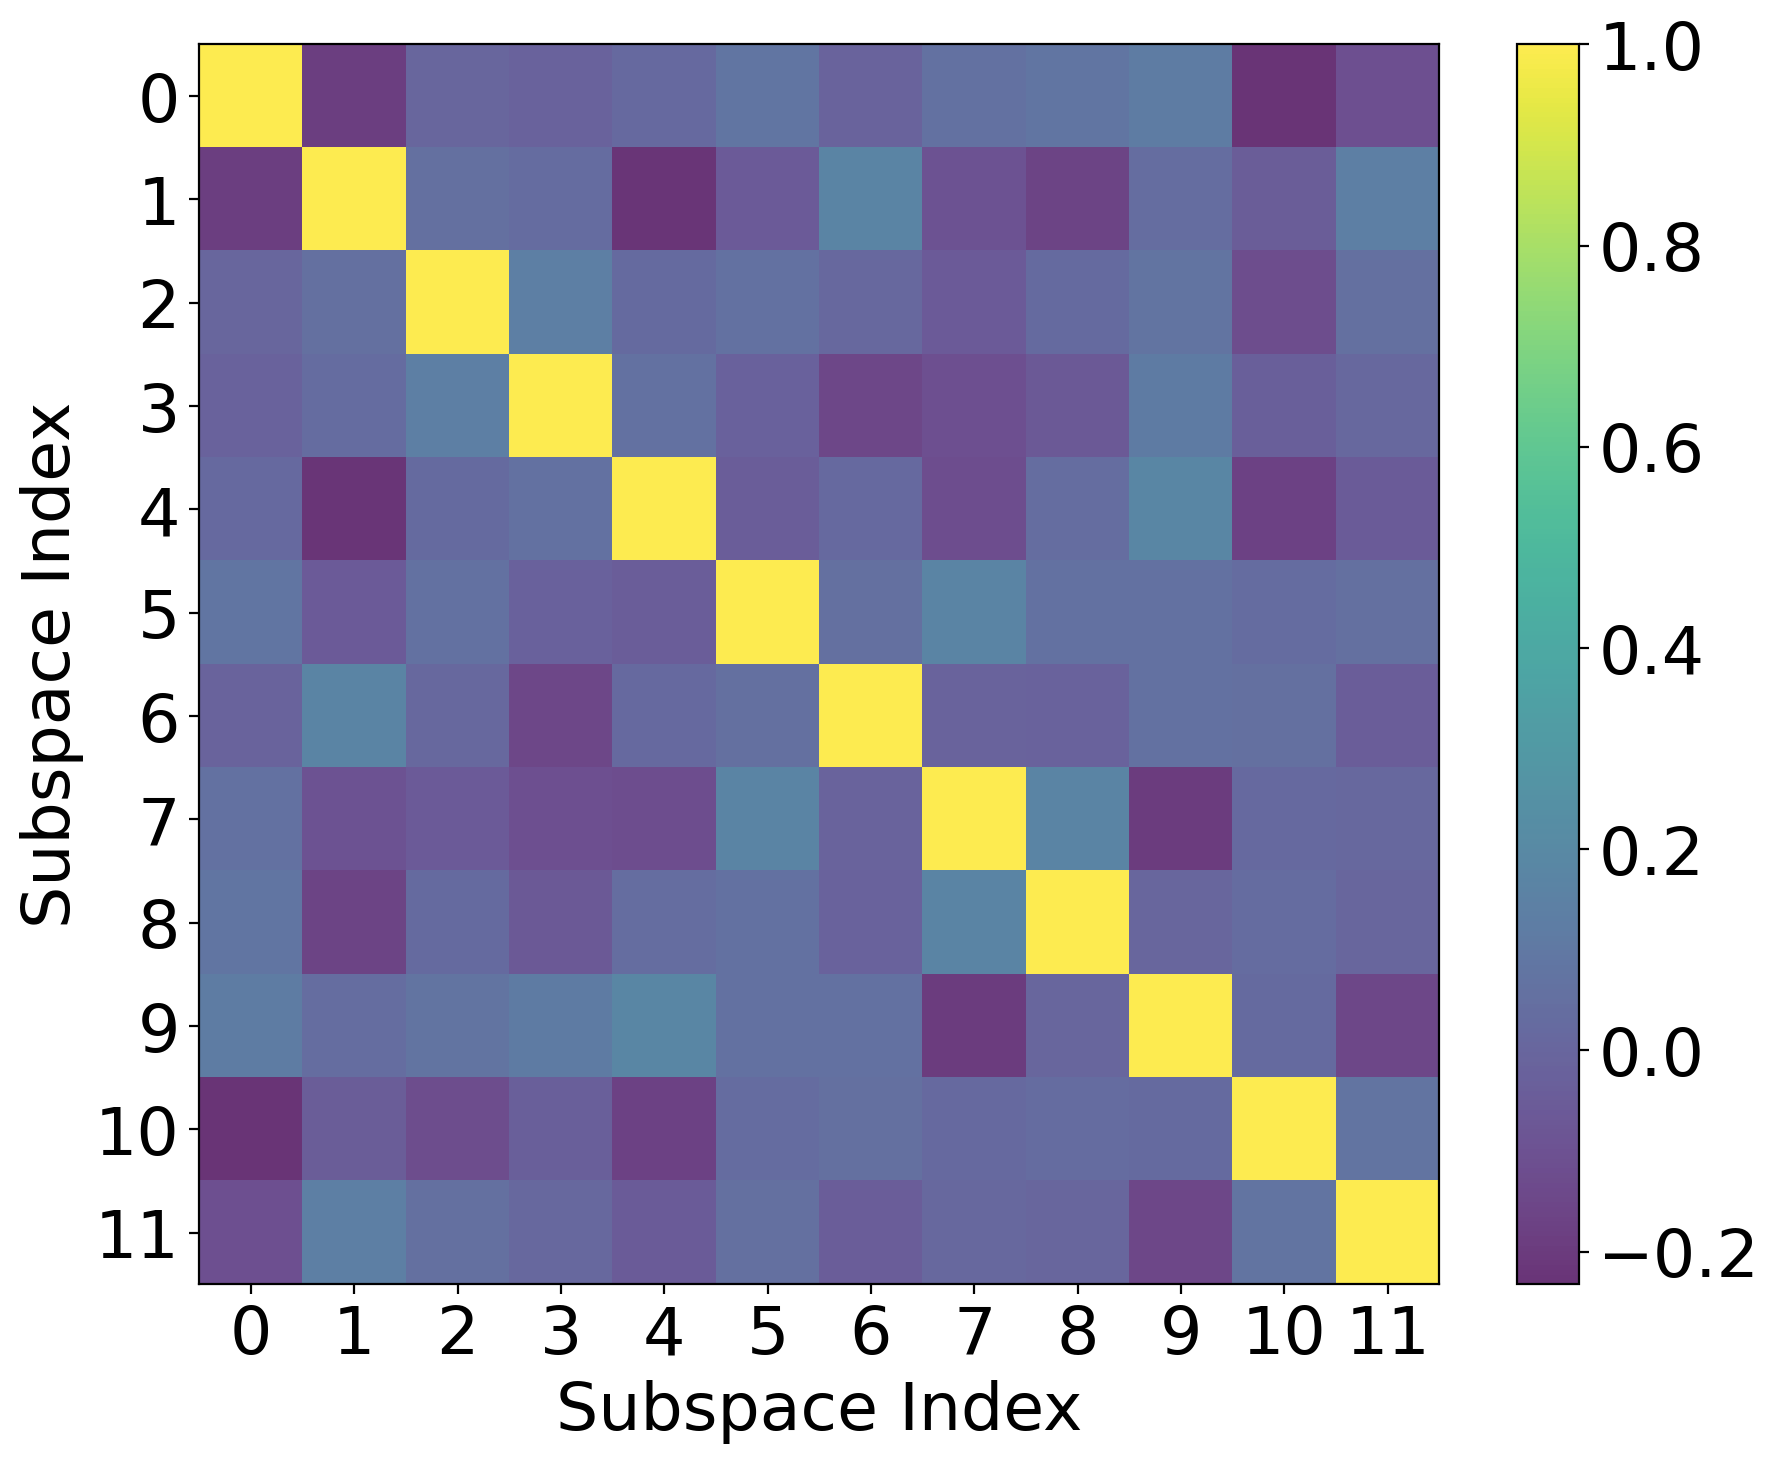

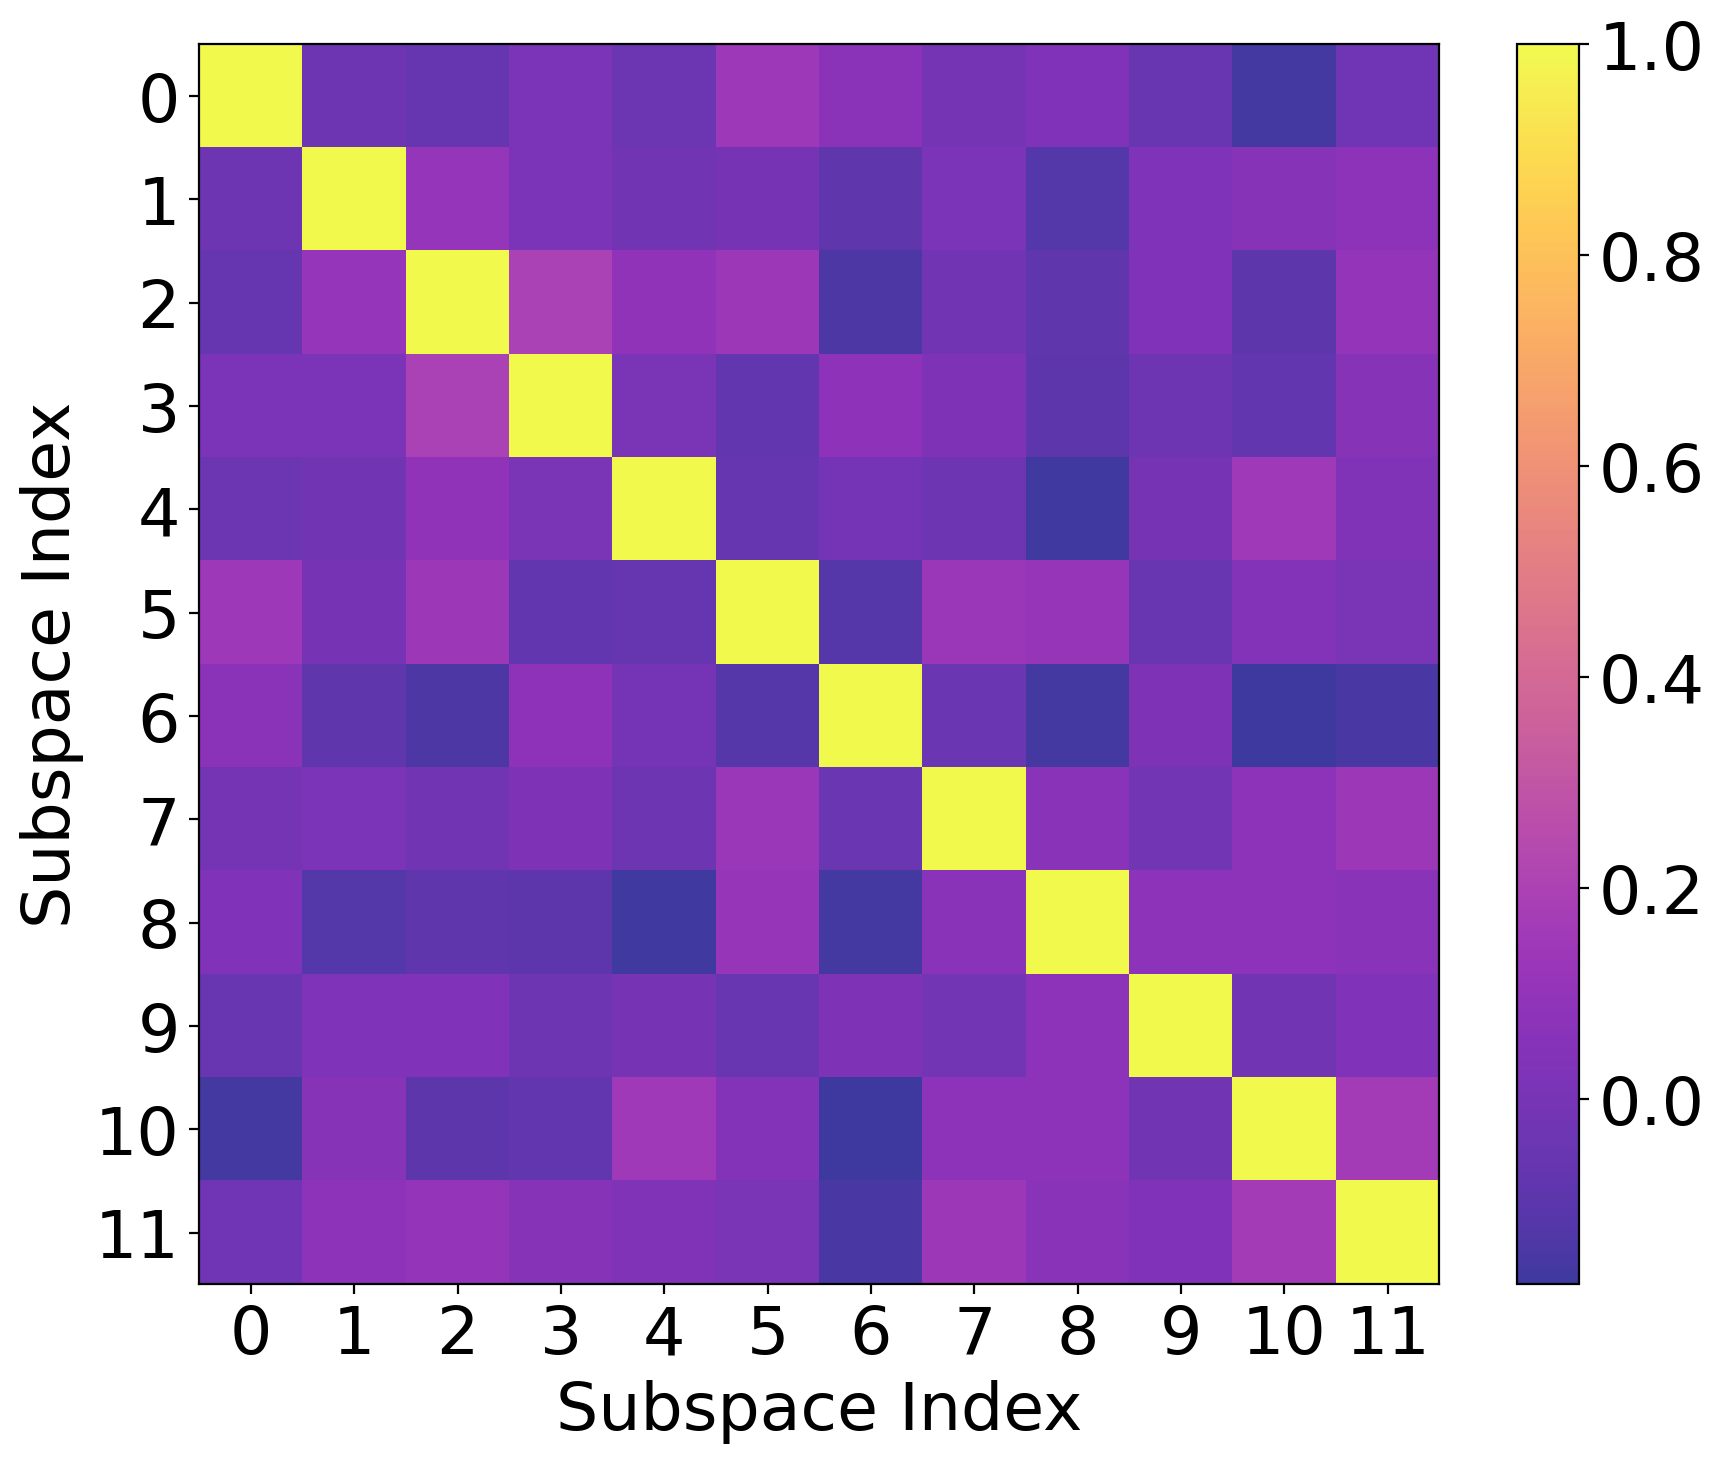

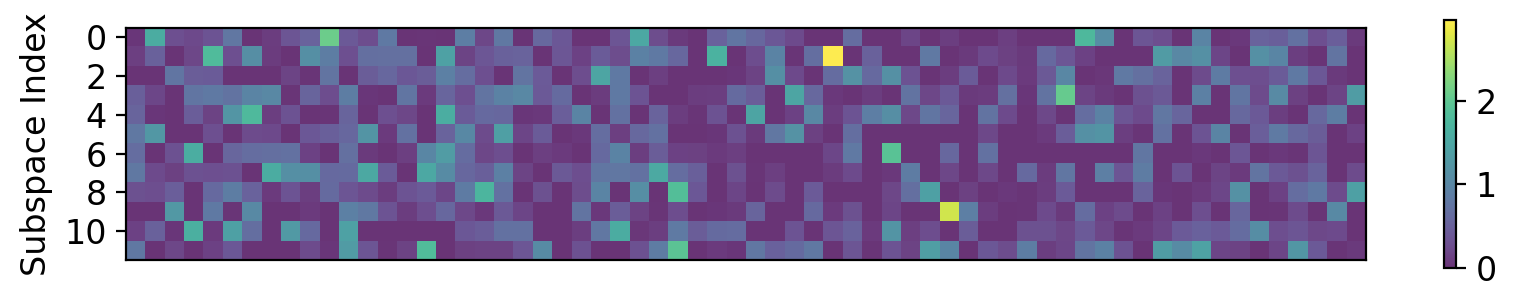

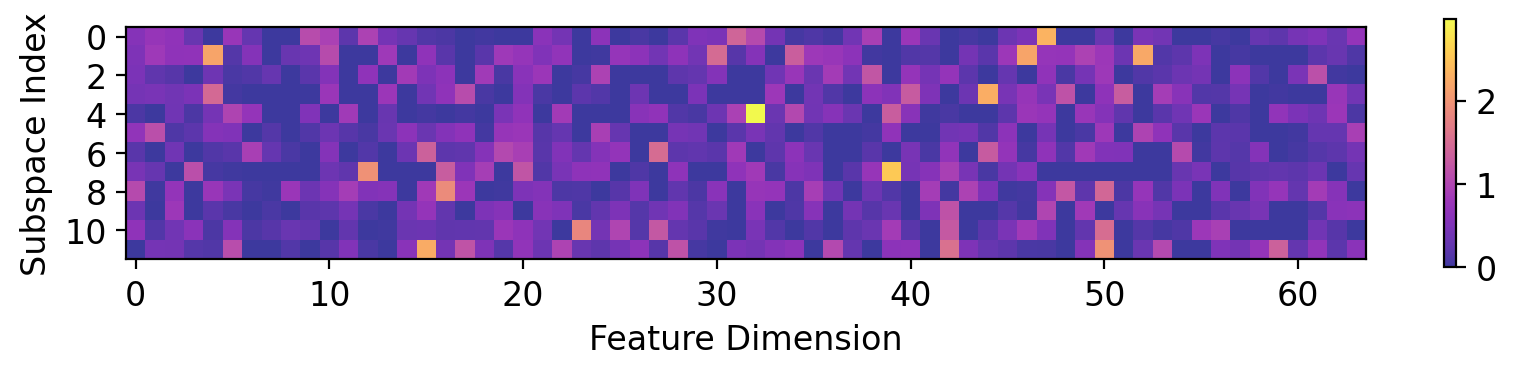

In [9]:
# one figure for each head to visualize the correlation between heads in the attention layer
plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 24})

alpha=0.8
# Plot the real part
plt.figure(figsize=(10, 10), dpi=200)  # Adjust the figure size as needed
plt.matshow(attention_corr_real, cmap='viridis', fignum=1, alpha = alpha)  # Use an appropriate colormap
plt.xlabel('Subspace Index')
plt.ylabel('Subspace Index')
plt.xticks(range(heads), range(heads))
plt.yticks(range(heads), range(heads))
# set x_ticks to the bottom
plt.gca().xaxis.set_ticks_position('bottom')
plt.colorbar(shrink=0.8)
# plt.savefig("figures/attention_corr_real" + ".pdf",dpi=200,bbox_inches = 'tight')
plt.show()


# Plot the imaginary part
plt.figure(figsize=(10, 10), dpi=200)  # Adjust the figure size as needed
plt.matshow(attention_corr_imag, cmap='plasma', fignum=1, alpha = alpha)  # Use an appropriate colormap
plt.xlabel('Subspace Index')
plt.ylabel('Subspace Index')
plt.xticks(range(heads), range(heads))
plt.yticks(range(heads), range(heads))
# set x_ticks to the bottom
plt.gca().xaxis.set_ticks_position('bottom')
plt.colorbar(shrink=0.8)
# plt.savefig("figures/attention_corr_imag" + ".pdf",dpi=200,bbox_inches = 'tight')
plt.show()



# one figure for each head to visualize the correlation between heads in the attention layer
plt.rcParams.update({'pdf.fonttype': 42})
plt.rcParams.update({'ps.fonttype': 42})
plt.rcParams.update({'font.size': 12})

alpha=0.8
# Plot the real part
plt.figure(figsize=(10, 20), dpi=200)  # Adjust the figure size as needed
plt.matshow(feature_sparsity_real, cmap='viridis', fignum=1, alpha = alpha)  # Use an appropriate colormap
# plt.xlabel('Feature Index')
# plt.ylabel('Subspace Index')
# plt.xticks(range(feature_sparsity_imag.shape[1]), range(feature_sparsity_imag.shape[1]))
# plt.yticks(range(heads), range(heads))
plt.gca().xaxis.set_ticks_position('bottom')
# no x_ticks
plt.xticks([])
plt.colorbar(shrink=0.08)

# plt.xlabel('Feature Index')
plt.ylabel('Subspace Index')
# plt.savefig("figures/feature_sparsity_real" + ".pdf",dpi=200,bbox_inches = 'tight')
# wider the y axis
plt.show()


# Plot the imaginary part
plt.figure(figsize=(10, 20), dpi=200)  # Adjust the figure size as needed
plt.matshow(feature_sparsity_imag, cmap='plasma', fignum=1, alpha = alpha)  # Use an appropriate colormap
plt.xlabel('Feature Dimension')
plt.ylabel('Subspace Index')
# plt.xticks(range(heads), range(heads))
# plt.yticks(range(heads), range(heads))
# set x_ticks to the bottom
plt.gca().xaxis.set_ticks_position('bottom')
plt.colorbar(shrink=0.08)
# plt.savefig("figures/feature_sparsity_imag" + ".pdf",dpi=200,bbox_inches = 'tight')
plt.show()

